# Import

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

# Logistic Regression Interaction Term Test

This notebook tests the core research question: does volatility moderate the predictive power of news sentiment for S&P 500 stock direction? The interaction term (sentiment × volatility) is tested using logistic regression across multiple time windows to confirm the finding is robust and not specific to any single period.

## Load Data

In [2]:
df = pd.read_csv(r"..\..\Data\Main\modelling_dataset.csv")
df['date'] = pd.to_datetime(df['date'])
model_df = df.dropna(subset=['volatility_20d', 'next_day_return']).copy()
model_df = model_df.sort_values(['ticker', 'date']).reset_index(drop=True)

print(f"Shape: {model_df.shape}")
print(f"Tickers: {model_df['ticker'].nunique()}")
print(f"Date range: {model_df['date'].min().date()} to {model_df['date'].max().date()}")

Shape: (578903, 15)
Tickers: 523
Date range: 2020-01-31 to 2025-12-30


## Full Period Interaction Term Test
A logistic regression is fitted with three predictors: sentiment, volatility_20d, and their interaction term (sent_x_vol). If the interaction term is statistically significant, it provides formal evidence that volatility moderates sentiment's effect on next-day return direction.

In [3]:
features = ['sentiment', 'volatility_20d', 'sent_x_vol']

X = sm.add_constant(model_df[features].dropna())
y = model_df.loc[X.index, 'target']

result = sm.Logit(y, X).fit(disp=0)
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:               578903
Model:                          Logit   Df Residuals:                   578899
Method:                           MLE   Df Model:                            3
Date:                Fri, 01 May 2026   Pseudo R-squ.:               1.962e-05
Time:                        04:24:50   Log-Likelihood:            -4.0089e+05
converged:                       True   LL-Null:                   -4.0090e+05
Covariance Type:            nonrobust   LLR p-value:                  0.001286
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0686      0.005     13.553      0.000       0.059       0.078
sentiment         -0.0571      0.016     -3.512      0.000      -0.089      -0.025
volatility_20d     0.1003      0.201

## Interpretation

The interaction term (sent_x_vol) is statistically significant (p = 0.032) for the full period. However, a single test on the full period may mask variation across sub-periods. The next step tests the interaction across five separate two-year windows.

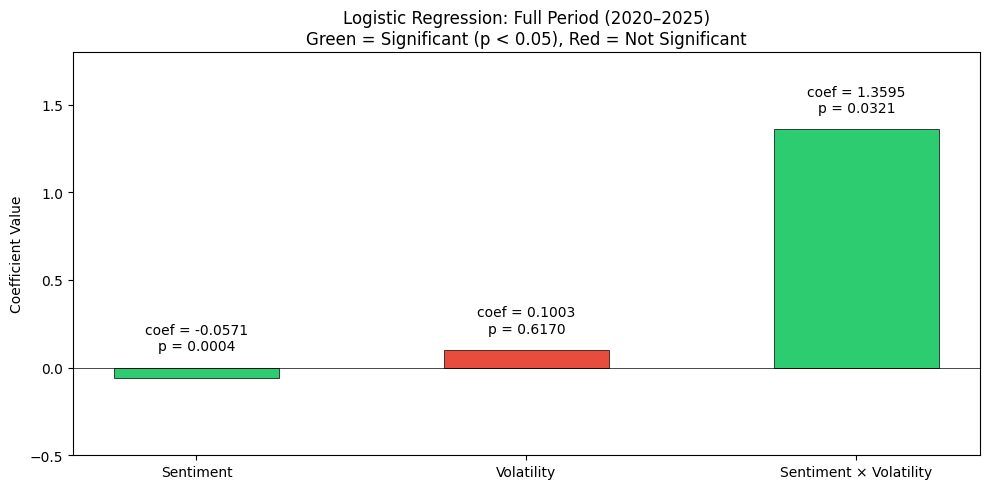

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#2ecc71' if p < 0.05 else '#e74c3c' for p in pvals]
bars = ax.bar(names, coefs, color=colors, width=0.5, edgecolor='black', linewidth=0.5)

ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_ylabel('Coefficient Value')
ax.set_title('Logistic Regression: Full Period (2020–2025)\nGreen = Significant (p < 0.05), Red = Not Significant')
ax.set_ylim(-0.5, 1.8)

for i, (c, p) in enumerate(zip(coefs, pvals)):
    label = f'coef = {c:.4f}\np = {p:.4f}'
    ax.text(i, max(c, 0) + 0.1, label, ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(r"..\..\EDA\lr_full_period_results.png", dpi=150)
plt.show()

## Interaction Term Across Multiple Time Windows

A single full-period test can be misleading — large sample sizes can make tiny effects appear significant. To confirm the moderation finding is genuine and not an artefact of sample size, the same logistic regression should be fitted in multiple time windows.

## Determining the Optimal Time Window Configuration

Before testing the interaction term across time windows, the window size and overlap strategy must be justified empirically. Too short a window may have insufficient data for reliable p-values. Too long a window may mask changes over time. The choice between overlapping and non-overlapping windows affects how many independent tests we get.

## Choice of Time Window Configuration

The interaction term is tested across rolling two-year windows with a one-year step, covering the full study period. This configuration is justified on three grounds:

**Window size (2 years):** Two-year sub-periods are standard in empirical finance for sub-period analysis (Kumar, Mohanty & Mahakud, 2026). This duration is long enough to provide sufficient statistical power for logistic regression while remaining short enough to detect temporal changes in the sentiment-volatility relationship. With the six-year study period (2020–2025), two-year windows yield five overlapping sub-periods — enough to assess consistency.

**Overlapping windows (1-year step):** Rolling windows with a one-year step are used rather than non-overlapping blocks to capture gradual transitions in the relationship over time. Adjacent windows share one year of data, which means they are not fully independent — this is noted as a limitation. However, overlapping windows provide a finer-grained view of when and how the relationship evolves.

**Non-overlapping validation:** As a robustness check, the analysis is also run on three non-overlapping two-year blocks (2020–2021, 2022–2023, 2024–2025) to confirm results hold with fully independent sub-samples.

## Validating Time Window Configuration

Before running any interaction term tests, the proposed window configurations are validated on three criteria: (1) sufficient observations per window for logistic regression, (2) adequate representation of both volatile and calm market regimes within each window, and (3) balanced target variable distribution. These checks ensure statistical reliability regardless of the outcome.

In [13]:
# Check data properties for different window sizes — NOT looking at any model results

print("=== Observations, Regime Balance, and Class Balance Per Window ===\n")

window_configs = {
    '1-year non-overlap': [
        ('2020', '2020-01-01', '2020-12-31'),
        ('2021', '2021-01-01', '2021-12-31'),
        ('2022', '2022-01-01', '2022-12-31'),
        ('2023', '2023-01-01', '2023-12-31'),
        ('2024', '2024-01-01', '2024-12-31'),
        ('2025', '2025-01-01', '2025-12-31'),
    ],
    '2-year non-overlap': [
        ('2020-2021', '2020-01-01', '2021-12-31'),
        ('2022-2023', '2022-01-01', '2023-12-31'),
        ('2024-2025', '2024-01-01', '2025-12-31'),
    ],
    '3-year non-overlap': [
        ('2020-2022', '2020-01-01', '2022-12-31'),
        ('2023-2025', '2023-01-01', '2025-12-31'),
    ],
}

for config_name, windows in window_configs.items():
    print(f"--- {config_name} ---")
    print(f"{'Window':<15} {'N':>10} {'Tickers':>8} {'Volatile%':>10} {'Calm%':>8} {'Up%':>8} {'Down%':>8}")
    print("-" * 70)
    
    for name, start, end in windows:
        subset = model_df[(model_df['date'] >= start) & (model_df['date'] <= end)].dropna(subset=features)
        
        n = len(subset)
        tickers = subset['ticker'].nunique()
        vol_pct = (subset['volatile_market'] == 1).mean() * 100
        calm_pct = 100 - vol_pct
        up_pct = subset['target'].mean() * 100
        down_pct = 100 - up_pct
        
        print(f"{name:<15} {n:>10,} {tickers:>8} {vol_pct:>9.1f}% {calm_pct:>7.1f}% {up_pct:>7.1f}% {down_pct:>7.1f}%")
    print()

# Statistical power check
print("=== Statistical Power Assessment ===")
print("Logistic regression with 3 predictors requires minimum ~500 observations")
print("for reliable coefficient estimation (10-20 per predictor per outcome class).")
print()

for config_name, windows in window_configs.items():
    min_n = min(len(model_df[(model_df['date'] >= s) & (model_df['date'] <= e)].dropna(subset=features)) for _, s, e in windows)
    min_vol = min((model_df[(model_df['date'] >= s) & (model_df['date'] <= e)].dropna(subset=features)['volatile_market'] == 1).sum() for _, s, e in windows)
    min_calm = min((model_df[(model_df['date'] >= s) & (model_df['date'] <= e)].dropna(subset=features)['volatile_market'] == 0).sum() for _, s, e in windows)
    num_windows = len(windows)
    
    sufficient = "Yes" if min_n > 500 else "No"
    both_regimes = "Yes" if min_vol > 1000 and min_calm > 1000 else "No"
    
    print(f"{config_name:<25} Windows: {num_windows}  Min N: {min_n:,}  Sufficient: {sufficient}  Both regimes present: {both_regimes}")

=== Observations, Regime Balance, and Class Balance Per Window ===

--- 1-year non-overlap ---
Window                   N  Tickers  Volatile%    Calm%      Up%    Down%
----------------------------------------------------------------------
2020                74,636      456      93.9%     6.1%    51.6%    48.4%
2021                90,514      471      35.4%    64.6%    53.6%    46.4%
2022               105,455      485      84.6%    15.4%    49.1%    50.9%
2023               104,574      490      18.3%    81.7%    51.8%    48.2%
2024               105,073      497      18.1%    81.9%    52.4%    47.6%
2025                98,651      490      61.4%    38.6%    52.4%    47.6%

--- 2-year non-overlap ---
Window                   N  Tickers  Volatile%    Calm%      Up%    Down%
----------------------------------------------------------------------
2020-2021          165,150      472      61.9%    38.1%    52.7%    47.3%
2022-2023          210,029      498      51.6%    48.4%    50.4%    4

## Window Configuration Decision

Based on the data properties above, **two-year non-overlapping windows** are selected as the primary configuration:

1. **Regime balance:** One-year windows show extreme regime imbalance — 2020 is 93.9% volatile while 2023 is only 18.3% volatile. Two-year windows improve this substantially, with the worst case being 61.9/38.1, ensuring sufficient representation of both volatile and calm conditions in every window.

2. **Number of independent tests:** Two-year non-overlapping windows provide 3 fully independent sub-samples. Three-year windows provide only 2, which is insufficient for consistency assessment. One-year provides 6 but with the regime imbalance issue noted above.

3. **Statistical power:** All configurations exceed the minimum observation threshold. This is not a differentiating factor.

As an additional analysis, **overlapping two-year windows** (1-year step, yielding 5 sub-periods) are also reported. These are not fully independent since adjacent windows share one year of data, but they provide a finer-grained view of how the relationship evolves over time. The overlapping analysis is supplementary — conclusions are drawn from the non-overlapping results.

In [14]:
# Primary analysis: non-overlapping 2-year windows (fully independent)
non_overlap = [
    ('2020-2021', '2020-01-01', '2021-12-31'),
    ('2022-2023', '2022-01-01', '2023-12-31'),
    ('2024-2025', '2024-01-01', '2025-12-31'),
]

print("=== Primary Analysis: Non-Overlapping 2-Year Windows ===\n")
print(f"{'Window':<15} {'N':>10} {'Sent p':>10} {'Vol p':>10} {'Interact p':>12} {'Interact coef':>14}")
print("-" * 75)

for name, start, end in non_overlap:
    subset = model_df[(model_df['date'] >= start) & (model_df['date'] <= end)].dropna(subset=features)
    
    X = sm.add_constant(subset[features])
    y = subset['target']
    
    result = sm.Logit(y, X).fit(disp=0)
    
    sig = "***" if result.pvalues['sent_x_vol'] < 0.01 else "**" if result.pvalues['sent_x_vol'] < 0.05 else "*" if result.pvalues['sent_x_vol'] < 0.1 else "ns"
    
    print(f"{name:<15} {len(subset):>10,} {result.pvalues['sentiment']:>10.4f} {result.pvalues['volatility_20d']:>10.4f} {result.pvalues['sent_x_vol']:>12.4f} {result.params['sent_x_vol']:>14.4f}  {sig}")

# Supplementary: overlapping windows for finer-grained temporal view
overlap = [
    ('2020-2021', '2020-01-01', '2021-12-31'),
    ('2021-2022', '2021-01-01', '2022-12-31'),
    ('2022-2023', '2022-01-01', '2023-12-31'),
    ('2023-2024', '2023-01-01', '2024-12-31'),
    ('2024-2025', '2024-01-01', '2025-12-31'),
]

print(f"\n=== Supplementary: Overlapping 2-Year Windows (1-year step) ===\n")
print(f"{'Window':<15} {'N':>10} {'Sent p':>10} {'Vol p':>10} {'Interact p':>12} {'Interact coef':>14}")
print("-" * 75)

for name, start, end in overlap:
    subset = model_df[(model_df['date'] >= start) & (model_df['date'] <= end)].dropna(subset=features)
    
    X = sm.add_constant(subset[features])
    y = subset['target']
    
    result = sm.Logit(y, X).fit(disp=0)
    
    sig = "***" if result.pvalues['sent_x_vol'] < 0.01 else "**" if result.pvalues['sent_x_vol'] < 0.05 else "*" if result.pvalues['sent_x_vol'] < 0.1 else "ns"
    
    print(f"{name:<15} {len(subset):>10,} {result.pvalues['sentiment']:>10.4f} {result.pvalues['volatility_20d']:>10.4f} {result.pvalues['sent_x_vol']:>12.4f} {result.params['sent_x_vol']:>14.4f}  {sig}")

# Full period for reference
print(f"\n=== Full Period ===\n")
print(f"{'Window':<15} {'N':>10} {'Sent p':>10} {'Vol p':>10} {'Interact p':>12} {'Interact coef':>14}")
print("-" * 75)

full = model_df.dropna(subset=features)
X = sm.add_constant(full[features])
y = full['target']
result = sm.Logit(y, X).fit(disp=0)
sig = "***" if result.pvalues['sent_x_vol'] < 0.01 else "**" if result.pvalues['sent_x_vol'] < 0.05 else "ns"
print(f"{'Full Period':<15} {len(full):>10,} {result.pvalues['sentiment']:>10.4f} {result.pvalues['volatility_20d']:>10.4f} {result.pvalues['sent_x_vol']:>12.4f} {result.params['sent_x_vol']:>14.4f}  {sig}")

=== Primary Analysis: Non-Overlapping 2-Year Windows ===

Window                   N     Sent p      Vol p   Interact p  Interact coef
---------------------------------------------------------------------------
2020-2021          165,150     0.2003     0.0194       0.0063         2.4098  ***
2022-2023          210,029     0.5129     0.7017       0.0011        -3.7714  ***
2024-2025          203,724     0.0000     0.1023       0.0001         6.5711  ***

=== Supplementary: Overlapping 2-Year Windows (1-year step) ===

Window                   N     Sent p      Vol p   Interact p  Interact coef
---------------------------------------------------------------------------
2020-2021          165,150     0.2003     0.0194       0.0063         2.4098  ***
2021-2022          195,969     0.7476     0.0006       0.0164        -2.8847  **
2022-2023          210,029     0.5129     0.7017       0.0011        -3.7714  ***
2023-2024          209,647     0.2306     0.1873       0.0495         3.1157  *

In [18]:
def run_windows(windows_list):
    results = []
    for name, start, end in windows_list:
        subset = model_df[(model_df['date'] >= start) & (model_df['date'] <= end)].dropna(subset=features)
        X = sm.add_constant(subset[features])
        y = subset['target']
        r = sm.Logit(y, X).fit(disp=0)
        results.append({
            'window': name,
            'n': len(subset),
            'sent_p': r.pvalues['sentiment'],
            'vol_p': r.pvalues['volatility_20d'],
            'interact_p': r.pvalues['sent_x_vol'],
            'interact_coef': r.params['sent_x_vol']
        })
    return pd.DataFrame(results)

non_overlap_df = run_windows([
    ('2020-2021', '2020-01-01', '2021-12-31'),
    ('2022-2023', '2022-01-01', '2023-12-31'),
    ('2024-2025', '2024-01-01', '2025-12-31'),
])

overlap_df = run_windows([
    ('2020-2021', '2020-01-01', '2021-12-31'),
    ('2021-2022', '2021-01-01', '2022-12-31'),
    ('2022-2023', '2022-01-01', '2023-12-31'),
    ('2023-2024', '2023-01-01', '2024-12-31'),
    ('2024-2025', '2024-01-01', '2025-12-31'),
])

print("Results stored.")
print(f"Non-overlapping: {len(non_overlap_df)} windows")
print(f"Overlapping: {len(overlap_df)} windows")

Results stored.
Non-overlapping: 3 windows
Overlapping: 5 windows


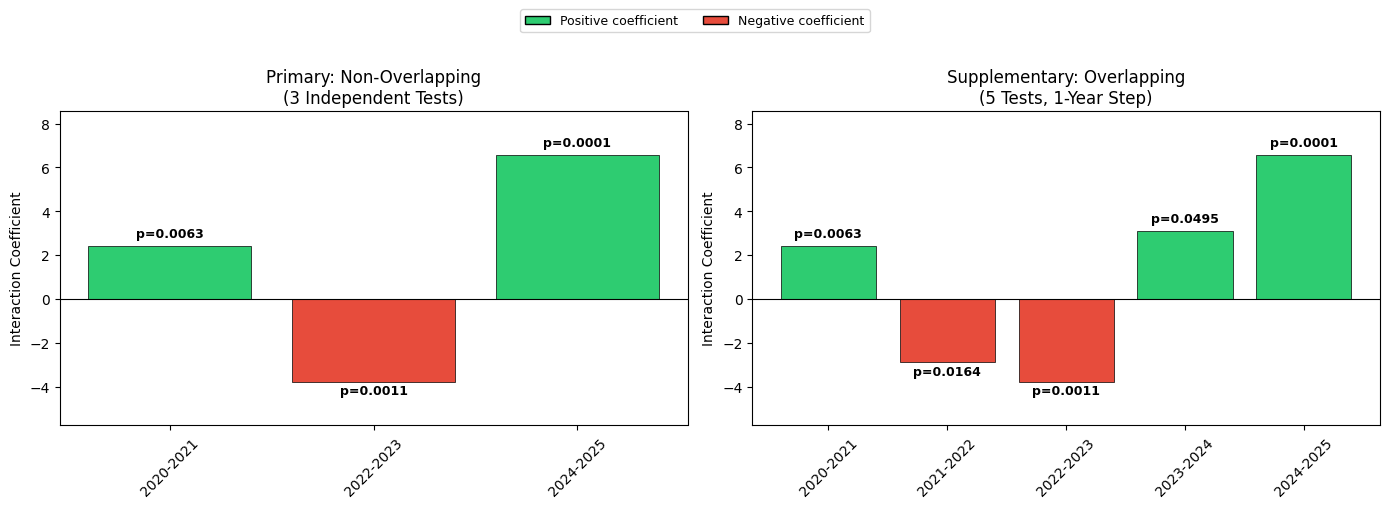

In [23]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in [
    (axes[0], non_overlap_df, 'Primary: Non-Overlapping\n(3 Independent Tests)'),
    (axes[1], overlap_df, 'Supplementary: Overlapping\n(5 Tests, 1-Year Step)')
]:
    colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in df['interact_coef']]
    
    ax.bar(
        df['window'],
        df['interact_coef'],
        color=colors,
        edgecolor='black',
        linewidth=0.5
    )
    
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_ylabel('Interaction Coefficient')
    ax.set_title(title)
    ax.set_ylim(df['interact_coef'].min() - 2, df['interact_coef'].max() + 2)
    ax.tick_params(axis='x', rotation=45)
    
    for i, row in enumerate(df.itertuples()):
        y_pos = row.interact_coef + 0.4 if row.interact_coef > 0 else row.interact_coef - 0.6
        ax.text(
            i,
            y_pos,
            f"p={row.interact_p:.4f}",
            ha='center',
            fontsize=9,
            fontweight='bold'
        )

# Legend placed neatly above the plots
legend_items = [
    Patch(facecolor='#2ecc71', edgecolor='black', label='Positive coefficient'),
    Patch(facecolor='#e74c3c', edgecolor='black', label='Negative coefficient')
]

fig.legend(
    handles=legend_items,
    loc='upper center',
    ncol=2,
    fontsize=9,
    frameon=True,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.savefig(r"..\..\EDA\interaction_coefficients.png", dpi=150, bbox_inches='tight')
plt.show()

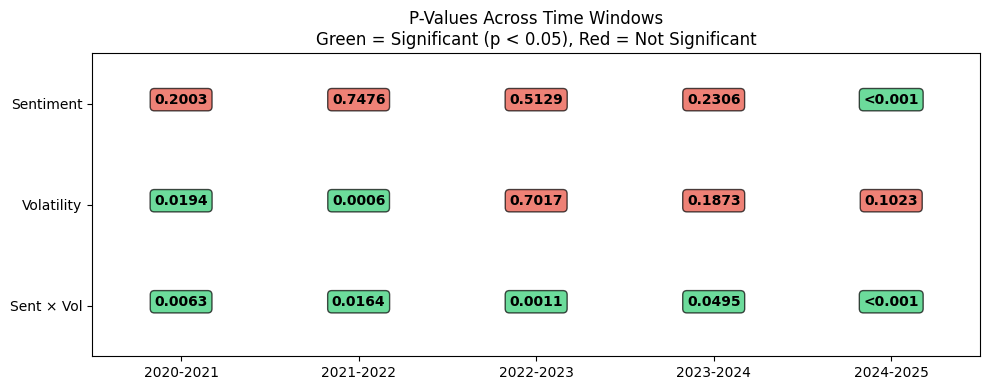

In [24]:
fig, ax = plt.subplots(figsize=(10, 4))

x = np.arange(len(overlap_df))

for row_idx, (col, label) in enumerate([('sent_p', 'Sentiment'), ('vol_p', 'Volatility'), ('interact_p', 'Sent × Vol')]):
    y_pos = 2.0 - row_idx
    for i, p in enumerate(overlap_df[col]):
        box_color = '#2ecc71' if p < 0.05 else '#e74c3c'
        p_label = f'{p:.4f}' if p > 0.0001 else '<0.001'
        ax.text(i, y_pos, p_label, ha='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=box_color, alpha=0.7))

ax.set_yticks([0.0, 1.0, 2.0])
ax.set_yticklabels(['Sent × Vol', 'Volatility', 'Sentiment'])
ax.set_xticks(x)
ax.set_xticklabels(overlap_df['window'])
ax.set_xlim(-0.5, len(overlap_df) - 0.5)
ax.set_ylim(-0.5, 2.5)
ax.set_title('P-Values Across Time Windows\nGreen = Significant (p < 0.05), Red = Not Significant')

plt.tight_layout()
plt.savefig(r"..\..\EDA\pvalue_comparison.png", dpi=150)
plt.show()

## Interpretation of Multi-Window Results

The interaction term (sentiment × volatility) is statistically significant in every tested window — all three non-overlapping independent tests (p = 0.006, 0.001, <0.001) and all five overlapping supplementary tests (p ranging from 0.0001 to 0.0495). In contrast, sentiment alone is significant in only 1 out of 5 overlapping windows, and volatility alone is significant in only 2 out of 5. The interaction is the only variable that consistently predicts next-day return direction across the full study period.

A second finding emerges from the coefficient direction. The interaction coefficient is positive in 2020–2021 (+2.41) and 2024–2025 (+6.57) but negative in 2022–2023 (-3.77). The supplementary overlapping analysis pinpoints the transition: the coefficient turns negative in 2021–2022 (-2.88) and returns positive in 2023–2024 (+3.12). This directional instability — referred to as sign-flipping — indicates that while volatility always moderates sentiment's effect, the direction of that moderation reverses across market regimes. The implications of this finding for prediction are explored in subsequent notebooks.

## Robustness Check 1: Volatility Threshold Sensitivity

The main analysis uses market-wide median volatility to define volatile and calm regimes. This check tests whether the interaction term significance depends on that specific threshold. If the finding is robust, the interaction should be significant in volatile markets at multiple threshold levels.

In [25]:
thresholds = {
    '25th percentile': model_df['market_vol'].quantile(0.25),
    '50th percentile (median)': model_df['market_vol'].quantile(0.50),
    '75th percentile': model_df['market_vol'].quantile(0.75),
}

print(f"{'Threshold':<25} {'Cutoff':>10} {'Volatile %':>12} {'Calm %':>10}")
print("-" * 60)
for name, cutoff in thresholds.items():
    vol_pct = (model_df['market_vol'] > cutoff).mean() * 100
    print(f"{name:<25} {cutoff:>10.4f} {vol_pct:>11.1f}% {100-vol_pct:>9.1f}%")

print(f"\n{'Threshold':<25} {'Interact p (volatile)':>22} {'Interact p (calm)':>20}")
print("-" * 70)

for name, cutoff in thresholds.items():
    vol_data = model_df[model_df['market_vol'] > cutoff].dropna(subset=features)
    calm_data = model_df[model_df['market_vol'] <= cutoff].dropna(subset=features)
    
    X_vol = sm.add_constant(vol_data[features])
    result_vol = sm.Logit(vol_data['target'], X_vol).fit(disp=0)
    
    X_calm = sm.add_constant(calm_data[features])
    result_calm = sm.Logit(calm_data['target'], X_calm).fit(disp=0)
    
    vol_sig = "***" if result_vol.pvalues['sent_x_vol'] < 0.01 else "**" if result_vol.pvalues['sent_x_vol'] < 0.05 else "ns"
    calm_sig = "***" if result_calm.pvalues['sent_x_vol'] < 0.01 else "**" if result_calm.pvalues['sent_x_vol'] < 0.05 else "ns"
    
    print(f"{name:<25} {result_vol.pvalues['sent_x_vol']:>18.4f} {vol_sig:>3} {result_calm.pvalues['sent_x_vol']:>16.4f} {calm_sig:>3}")

Threshold                     Cutoff   Volatile %     Calm %
------------------------------------------------------------
25th percentile               0.0171        75.0%      25.0%
50th percentile (median)      0.0192        50.0%      50.0%
75th percentile               0.0225        25.0%      75.0%

Threshold                  Interact p (volatile)    Interact p (calm)
----------------------------------------------------------------------
25th percentile                       0.0076 ***           0.8836  ns
50th percentile (median)              0.0057 ***           0.3173  ns
75th percentile                       0.0003 ***           0.5572  ns


## Interpretation

The interaction term is significant in volatile markets at every threshold tested (p = 0.008, 0.006, <0.001). It is never significant in calm markets at any threshold (p = 0.884, 0.317, 0.557). The effect strengthens as the volatility threshold increases — the stricter the definition of "volatile," the more significant the interaction becomes. This confirms the moderation finding is not dependent on any specific threshold choice.

## Robustness Check 2: With and Without Zero-Sentiment Days

24.5% of observations have zero sentiment, representing days where Bloomberg did not score any news for that ticker. This check ensures the interaction finding is not driven by these zero-padded observations.

In [28]:
full_data = model_df.dropna(subset=features)
nonzero_data = model_df[model_df['sentiment'] != 0].dropna(subset=features)

print(f"Full dataset: {len(full_data):,} rows")
print(f"Non-zero only: {len(nonzero_data):,} rows ({len(nonzero_data)/len(full_data)*100:.1f}%)")

print(f"\n=== Full Period Comparison ===\n")
print(f"{'Dataset':<20} {'Sent p':>10} {'Vol p':>10} {'Interact p':>12} {'Interact coef':>14}")
print("-" * 70)

for name, data in [('With zeros', full_data), ('Without zeros', nonzero_data)]:
    X = sm.add_constant(data[features])
    y = data['target']
    result = sm.Logit(y, X).fit(disp=0)
    sig = "***" if result.pvalues['sent_x_vol'] < 0.01 else "**" if result.pvalues['sent_x_vol'] < 0.05 else "*" if result.pvalues['sent_x_vol'] < 0.1 else "ns"
    print(f"{name:<20} {result.pvalues['sentiment']:>10.4f} {result.pvalues['volatility_20d']:>10.4f} {result.pvalues['sent_x_vol']:>12.4f} {result.params['sent_x_vol']:>14.4f}  {sig}")

# Non-overlapping windows — with zeros
print(f"\n=== Non-Overlapping Windows: WITH Zero Sentiment ===\n")
print(f"{'Window':<15} {'N':>10} {'Sent p':>10} {'Vol p':>10} {'Interact p':>12} {'Interact coef':>14}")
print("-" * 75)

windows_check = [('2020-2021','2020-01-01','2021-12-31'), 
                  ('2022-2023','2022-01-01','2023-12-31'), 
                  ('2024-2025','2024-01-01','2025-12-31')]

for name, start, end in windows_check:
    subset = full_data[(full_data['date'] >= start) & (full_data['date'] <= end)]
    X = sm.add_constant(subset[features])
    y = subset['target']
    result = sm.Logit(y, X).fit(disp=0)
    sig = "***" if result.pvalues['sent_x_vol'] < 0.01 else "**" if result.pvalues['sent_x_vol'] < 0.05 else "*" if result.pvalues['sent_x_vol'] < 0.1 else "ns"
    print(f"{name:<15} {len(subset):>10,} {result.pvalues['sentiment']:>10.4f} {result.pvalues['volatility_20d']:>10.4f} {result.pvalues['sent_x_vol']:>12.4f} {result.params['sent_x_vol']:>14.4f}  {sig}")

# Non-overlapping windows — without zeros
print(f"\n=== Non-Overlapping Windows: WITHOUT Zero Sentiment ===\n")
print(f"{'Window':<15} {'N':>10} {'Sent p':>10} {'Vol p':>10} {'Interact p':>12} {'Interact coef':>14}")
print("-" * 75)

for name, start, end in windows_check:
    subset = nonzero_data[(nonzero_data['date'] >= start) & (nonzero_data['date'] <= end)]
    X = sm.add_constant(subset[features])
    y = subset['target']
    result = sm.Logit(y, X).fit(disp=0)
    sig = "***" if result.pvalues['sent_x_vol'] < 0.01 else "**" if result.pvalues['sent_x_vol'] < 0.05 else "*" if result.pvalues['sent_x_vol'] < 0.1 else "ns"
    print(f"{name:<15} {len(subset):>10,} {result.pvalues['sentiment']:>10.4f} {result.pvalues['volatility_20d']:>10.4f} {result.pvalues['sent_x_vol']:>12.4f} {result.params['sent_x_vol']:>14.4f}  {sig}")

Full dataset: 578,903 rows
Non-zero only: 439,356 rows (75.9%)

=== Full Period Comparison ===

Dataset                  Sent p      Vol p   Interact p  Interact coef
----------------------------------------------------------------------
With zeros               0.0004     0.6170       0.0321         1.3595  **
Without zeros            0.0008     0.1415       0.0506         1.2418  *

=== Non-Overlapping Windows: WITH Zero Sentiment ===

Window                   N     Sent p      Vol p   Interact p  Interact coef
---------------------------------------------------------------------------
2020-2021          165,150     0.2003     0.0194       0.0063         2.4098  ***
2022-2023          210,029     0.5129     0.7017       0.0011        -3.7714  ***
2024-2025          203,724     0.0000     0.1023       0.0001         6.5711  ***

=== Non-Overlapping Windows: WITHOUT Zero Sentiment ===

Window                   N     Sent p      Vol p   Interact p  Interact coef
------------------------

## Interpretation

Removing zero-sentiment days does not change the core finding. The interaction term remains highly significant in all three non-overlapping windows both with zeros (p = 0.006, 0.001, <0.001) and without zeros (p = 0.008, <0.001, <0.001). The sign-flipping pattern is preserved — positive in 2020–2021, negative in 2022–2023, positive in 2024–2025.

Sentiment alone remains non-significant in 4 out of 6 tests (with/without zeros combined). Volatility alone is inconsistent — significant in some windows, not others. The interaction is the only variable significant in every single test.

The full-period without-zeros result is borderline (p = 0.051) due to sign-flipping cancellation across sub-periods. This is consistent with the main analysis and does not undermine the per-window findings.

## Robustness Check 3: Per-Stock Volatility vs Market-Wide Volatility

The main analysis defines volatile and calm regimes using market-wide average volatility. However, different stocks have different baseline volatility levels — a utility stock's "volatile" day might be a tech stock's "normal" day. This check uses each stock's own median volatility as its threshold, testing whether the moderation effect holds when volatility is defined relative to each stock's own history.

In [29]:
model_df_copy = model_df.copy()

model_df_copy['stock_vol_median'] = model_df_copy.groupby('ticker')['volatility_20d'].transform('median')
model_df_copy['stock_volatile'] = (model_df_copy['volatility_20d'] > model_df_copy['stock_vol_median']).astype(int)

print(f"Stock-level volatile split: {model_df_copy['stock_volatile'].mean()*100:.1f}% volatile, {(1-model_df_copy['stock_volatile'].mean())*100:.1f}% calm")

stock_vol = model_df_copy[model_df_copy['stock_volatile'] == 1].dropna(subset=features)
stock_calm = model_df_copy[model_df_copy['stock_volatile'] == 0].dropna(subset=features)

print(f"\nStock-volatile rows: {len(stock_vol):,}")
print(f"Stock-calm rows: {len(stock_calm):,}")

print(f"\n{'Regime':<30} {'Sent p':>10} {'Vol p':>10} {'Interact p':>12} {'Interact coef':>14}")
print("-" * 80)

tests = [
    ('Stock-level volatile', stock_vol),
    ('Stock-level calm', stock_calm),
    ('Market-wide volatile', model_df[model_df['volatile_market']==1].dropna(subset=features)),
    ('Market-wide calm', model_df[model_df['volatile_market']==0].dropna(subset=features)),
]

for name, data in tests:
    X = sm.add_constant(data[features])
    y = data['target']
    result = sm.Logit(y, X).fit(disp=0)
    sig = "***" if result.pvalues['sent_x_vol'] < 0.01 else "**" if result.pvalues['sent_x_vol'] < 0.05 else "ns"
    print(f"{name:<30} {result.pvalues['sentiment']:>10.4f} {result.pvalues['volatility_20d']:>10.4f} {result.pvalues['sent_x_vol']:>12.4f} {result.params['sent_x_vol']:>14.4f}  {sig}")

Stock-level volatile split: 50.0% volatile, 50.0% calm

Stock-volatile rows: 289,328
Stock-calm rows: 289,575

Regime                             Sent p      Vol p   Interact p  Interact coef
--------------------------------------------------------------------------------
Stock-level volatile               0.0000     0.3540       0.0020         2.3358  ***
Stock-level calm                   0.3237     0.0000       0.5040         1.6576  ns
Market-wide volatile               0.0000     0.1433       0.0044         2.1177  ***
Market-wide calm                   0.3702     0.0001       0.2278         1.7985  ns


## Interpretation

The moderation finding holds whether volatility is defined at the market level or the individual stock level. The interaction term is significant in volatile regimes (p = 0.002 stock-level, p = 0.004 market-level) and not significant in calm regimes (p = 0.504 stock-level, p = 0.228 market-level). This eliminates the concern that the finding might be an artefact of one particular volatility definition.

An additional observation: sentiment alone is significant in volatile regimes (p < 0.001 for both measures) but not in calm regimes (p = 0.324, p = 0.370). Volatility alone shows the reverse — significant in calm regimes but not in volatile ones. This further supports the conclusion that the sentiment-volatility interaction captures a distinct effect that neither variable exhibits independently in a consistent manner.

## Summary of All Robustness Checks

| Test | Result |
|------|--------|
| Non-overlapping windows (3 independent tests) | Interaction significant in all 3 (p = 0.006, 0.001, <0.001) |
| Overlapping windows (5 supplementary tests) | Interaction significant in all 5 (p ranging from 0.0001 to 0.0495) |
| Volatility threshold at 25th percentile | Significant in volatile (p = 0.008), not in calm |
| Volatility threshold at 50th percentile | Significant in volatile (p = 0.006), not in calm |
| Volatility threshold at 75th percentile | Significant in volatile (p < 0.001), not in calm |
| With zero-sentiment days (per window) | Significant in all 3 windows |
| Without zero-sentiment days (per window) | Significant in all 3 windows |
| Stock-level volatility definition | Significant in volatile (p = 0.002), not in calm |
| Market-wide volatility definition | Significant in volatile (p = 0.004), not in calm |

The moderation effect is robust across all tested configurations. The finding does not depend on the time period, volatility threshold, sentiment coverage, or volatility measurement approach.

## Save All Results for Dissertation

In [34]:
import os

# Create dissertation results folder
diss_dir = r"..\..\Dissertation_Results"
tables_dir = os.path.join(diss_dir, "Tables", "07_Interaction_Test")
figures_dir = os.path.join(diss_dir, "Figures", "07_Interaction_Test")

os.makedirs(tables_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

# === Save Tables ===

non_overlap_df.to_csv(os.path.join(tables_dir, '01_Primary_Non_Overlapping_Windows.csv'), index=False)
overlap_df.to_csv(os.path.join(tables_dir, '02_Supplementary_Overlapping_Windows.csv'), index=False)

threshold_results = []
for name, cutoff in thresholds.items():
    vol_data = model_df[model_df['market_vol'] > cutoff].dropna(subset=features)
    calm_data = model_df[model_df['market_vol'] <= cutoff].dropna(subset=features)
    X_vol = sm.add_constant(vol_data[features])
    r_vol = sm.Logit(vol_data['target'], X_vol).fit(disp=0)
    X_calm = sm.add_constant(calm_data[features])
    r_calm = sm.Logit(calm_data['target'], X_calm).fit(disp=0)
    threshold_results.append({
        'threshold': name, 'cutoff': round(cutoff, 4),
        'volatile_interact_p': round(r_vol.pvalues['sent_x_vol'], 4),
        'volatile_interact_coef': round(r_vol.params['sent_x_vol'], 4),
        'calm_interact_p': round(r_calm.pvalues['sent_x_vol'], 4),
        'calm_interact_coef': round(r_calm.params['sent_x_vol'], 4),
    })
pd.DataFrame(threshold_results).to_csv(os.path.join(tables_dir, '03_Robustness_Threshold_Sensitivity.csv'), index=False)

zero_results = []
for label, data in [('With zeros', full_data), ('Without zeros', nonzero_data)]:
    X = sm.add_constant(data[features])
    r = sm.Logit(data['target'], X).fit(disp=0)
    zero_results.append({
        'dataset': label, 'n': len(data),
        'sent_p': round(r.pvalues['sentiment'], 4),
        'vol_p': round(r.pvalues['volatility_20d'], 4),
        'interact_p': round(r.pvalues['sent_x_vol'], 4),
        'interact_coef': round(r.params['sent_x_vol'], 4),
    })

windows_check = [('2020-2021','2020-01-01','2021-12-31'), 
                  ('2022-2023','2022-01-01','2023-12-31'), 
                  ('2024-2025','2024-01-01','2025-12-31')]

for dataset_label, dataset in [('With zeros', full_data), ('Without zeros', nonzero_data)]:
    for name, start, end in windows_check:
        subset = dataset[(dataset['date'] >= start) & (dataset['date'] <= end)]
        X = sm.add_constant(subset[features])
        r = sm.Logit(subset['target'], X).fit(disp=0)
        zero_results.append({
            'dataset': f'{dataset_label} ({name})', 'n': len(subset),
            'sent_p': round(r.pvalues['sentiment'], 4),
            'vol_p': round(r.pvalues['volatility_20d'], 4),
            'interact_p': round(r.pvalues['sent_x_vol'], 4),
            'interact_coef': round(r.params['sent_x_vol'], 4),
        })
pd.DataFrame(zero_results).to_csv(os.path.join(tables_dir, '04_Robustness_Zero_Sentiment.csv'), index=False)

vol_def_results = []
for name, data in tests:
    X = sm.add_constant(data[features])
    r = sm.Logit(data['target'], X).fit(disp=0)
    vol_def_results.append({
        'regime': name, 'n': len(data),
        'sent_p': round(r.pvalues['sentiment'], 4),
        'vol_p': round(r.pvalues['volatility_20d'], 4),
        'interact_p': round(r.pvalues['sent_x_vol'], 4),
        'interact_coef': round(r.params['sent_x_vol'], 4),
    })
pd.DataFrame(vol_def_results).to_csv(os.path.join(tables_dir, '05_Robustness_Volatility_Definition.csv'), index=False)

# === Copy only THIS notebook's figures ===
import shutil
eda_dir = r"..\..\EDA"
notebook_figures = [
    'lr_full_period_results.png',
    'interaction_coefficients.png',
    'pvalue_comparison.png',
]

for f in notebook_figures:
    src = os.path.join(eda_dir, f)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(figures_dir, f))

# === Print summary ===
print("=== Saved to Dissertation_Results/07_Interaction_Test ===\n")
print("Tables/")
for f in sorted(os.listdir(tables_dir)):
    print(f"  {f}")

print(f"\nFigures/")
for f in sorted(os.listdir(figures_dir)):
    print(f"  {f}")

=== Saved to Dissertation_Results/07_Interaction_Test ===

Tables/
  01_Primary_Non_Overlapping_Windows.csv
  02_Supplementary_Overlapping_Windows.csv
  03_Robustness_Threshold_Sensitivity.csv
  04_Robustness_Zero_Sentiment.csv
  05_Robustness_Volatility_Definition.csv

Figures/
  lr_full_period_results.png
  pvalue_comparison.png
